In [22]:
import numpy as np
import pandas as pd
import tabula 
import jpype

In [25]:
doc = tabula.read_pdf(
    "NCRB_STATS.pdf",
    pages="all",
    multiple_tables=True,
    force_subprocess=True,
    encoding="latin-1"
)

In [26]:
# no. of tables
print(type(doc))
print(len(doc))

<class 'list'>
495


In [27]:
doc[37].head()

,Unnamed: 0,Unnamed: 1,Offences affecting the Human Body
0,NaN,NaN,Assault on Women with Intent to Hurt
1,NaN,NaN,Outrage her Modesty
2,NaN,NaN,Grievous Hurt Wrongful
3,SL State/UT,NaN,Restraint/Confinement Assault on Women with In...
4,NaN,NaN,G) Other Grievous Hurt (Sec.341 to 348 IPC) Ou...


In [28]:
#getting tables 
for i in range(20):
    print(f"\nTable {i}")
    print(doc[i].shape)


Table 0
(3, 10)

Table 1
(0, 3)

Table 2
(3, 3)

Table 3
(0, 2)

Table 4
(13, 4)

Table 5
(18, 5)

Table 6
(11, 6)

Table 7
(22, 8)

Table 8
(10, 7)

Table 9
(8, 7)

Table 10
(0, 1)

Table 11
(8, 1)

Table 12
(7, 8)

Table 13
(9, 8)

Table 14
(24, 6)

Table 15
(9, 5)

Table 16
(38, 9)

Table 17
(38, 9)

Table 18
(38, 9)

Table 19
(36, 9)


In [29]:
#filtering out junk tables
for i, table in enumerate(doc):
    if len(table) > 20:  # more than 20 rows
        print(f"Table {i}: {table.shape}")

Table 7: (22, 8)
Table 14: (24, 6)
Table 16: (38, 9)
Table 17: (38, 9)
Table 18: (38, 9)
Table 19: (36, 9)
Table 20: (32, 9)
Table 21: (32, 9)
Table 22: (33, 9)
Table 23: (39, 8)
Table 25: (39, 8)
Table 26: (39, 8)
Table 27: (49, 5)
Table 28: (50, 3)
Table 29: (49, 5)
Table 30: (48, 6)
Table 31: (47, 5)
Table 32: (50, 7)
Table 33: (53, 4)
Table 34: (53, 4)
Table 35: (53, 4)
Table 36: (52, 5)
Table 37: (51, 3)
Table 38: (51, 3)
Table 39: (51, 4)
Table 40: (49, 3)
Table 41: (51, 4)
Table 42: (51, 3)
Table 43: (50, 5)
Table 44: (49, 3)
Table 45: (47, 5)
Table 46: (49, 5)
Table 47: (47, 5)
Table 48: (50, 8)
Table 49: (48, 9)
Table 50: (48, 10)
Table 51: (48, 9)
Table 52: (50, 9)
Table 53: (51, 4)
Table 54: (50, 4)
Table 55: (48, 5)
Table 56: (48, 5)
Table 57: (49, 5)
Table 58: (49, 4)
Table 59: (50, 5)
Table 60: (48, 5)
Table 61: (50, 3)
Table 62: (49, 3)
Table 63: (51, 5)
Table 64: (50, 3)
Table 65: (50, 4)
Table 66: (51, 5)
Table 67: (51, 3)
Table 68: (51, 5)
Table 69: (47, 5)
Table 70: 

In [30]:
type(doc[37])

pandas.core.frame.DataFrame

In [ ]:
doc[7]

In [31]:
def clean_table(df):
    df = df.dropna(how='all')
    df = df.dropna(axis=1, how='all')
    df = df.ffill()
    return df

In [35]:
df=clean_table(doc[37])

In [36]:
df = df.iloc[9:37]
df = df.reset_index(drop=True)

print(df.head())

            Unnamed: 0     Offences affecting the Human Body
0     1 Andhra Pradesh  2 2 0.0 1800 1849 3.4 5884 6118 22.2
1  2 Arunachal Pradesh             3 3 0.2 1 1 0.1 67 77 8.9
2              3 Assam  94 94 0.3 148 162 0.4 1984 2168 11.4
3              4 Bihar       281 283 0.2 0 0 0.0 402 403 0.7
4       5 Chhattisgarh     3 3 0.0 109 109 0.4 1322 1329 8.9


In [37]:
print(df.iloc[0].to_string())

Unnamed: 0                                               1 Andhra Pradesh
Offences affecting the Human Body    2 2 0.0 1800 1849 3.4 5884 6118 22.2


In [38]:
import re

df["State"] = df["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

print(df[["State"]].head())

               State
0     Andhra Pradesh
1  Arunachal Pradesh
2              Assam
3              Bihar
4       Chhattisgarh


In [39]:
df["Offences affecting the Human Body"].head()

0    2 2 0.0 1800 1849 3.4 5884 6118 22.2
1               3 3 0.2 1 1 0.1 67 77 8.9
2    94 94 0.3 148 162 0.4 1984 2168 11.4
3         281 283 0.2 0 0 0.0 402 403 0.7
4       3 3 0.0 109 109 0.4 1322 1329 8.9
Name: Offences affecting the Human Body, dtype: object

In [40]:
crime_cols = df["Offences affecting the Human Body"].str.split(
    expand=True
)

print(crime_cols.head())

     0    1    2     3     4    5     6     7     8
0    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1    3    3  0.2     1     1  0.1    67    77   8.9
2   94   94  0.3   148   162  0.4  1984  2168  11.4
3  281  283  0.2     0     0  0.0   402   403   0.7
4    3    3  0.0   109   109  0.4  1322  1329   8.9


In [41]:
final_df = pd.concat(
    [df["State"], crime_cols],
    axis=1
)

print(final_df.head())

               State    0    1    2     3     4    5     6     7     8
0     Andhra Pradesh    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1  Arunachal Pradesh    3    3  0.2     1     1  0.1    67    77   8.9
2              Assam   94   94  0.3   148   162  0.4  1984  2168  11.4
3              Bihar  281  283  0.2     0     0  0.0   402   403   0.7
4       Chhattisgarh    3    3  0.0   109   109  0.4  1322  1329   8.9


In [43]:
print(doc[37].iloc[:9].to_string())

    Unnamed: 0  Unnamed: 1                                        Offences affecting the Human Body
0          NaN         NaN                                     Assault on Women with Intent to Hurt
1          NaN         NaN                                                      Outrage her Modesty
2          NaN         NaN                                                   Grievous Hurt Wrongful
3  SL State/UT         NaN                    Restraint/Confinement Assault on Women with Intent to
4          NaN         NaN  G) Other Grievous Hurt (Sec.341 to 348 IPC) Outrage her Modesty (Total)
5          NaN         NaN                                                     (Sec.329, 331 & 335)
6          NaN         NaN                                                        I V R I V R I V R
7      [1] [2]         NaN                           [93] [94] [95] [96] [97] [98] [99] [100] [101]
8      STATES:         NaN                                                                      NaN


In [44]:
print(doc[37].iloc[:9].to_string())

    Unnamed: 0  Unnamed: 1                                        Offences affecting the Human Body
0          NaN         NaN                                     Assault on Women with Intent to Hurt
1          NaN         NaN                                                      Outrage her Modesty
2          NaN         NaN                                                   Grievous Hurt Wrongful
3  SL State/UT         NaN                    Restraint/Confinement Assault on Women with Intent to
4          NaN         NaN  G) Other Grievous Hurt (Sec.341 to 348 IPC) Outrage her Modesty (Total)
5          NaN         NaN                                                     (Sec.329, 331 & 335)
6          NaN         NaN                                                        I V R I V R I V R
7      [1] [2]         NaN                           [93] [94] [95] [96] [97] [98] [99] [100] [101]
8      STATES:         NaN                                                                      NaN


In [45]:
print(df.shape)

(28, 3)


In [46]:
print(df.columns.tolist())

['Unnamed: 0', 'Offences affecting the Human Body', 'State']


In [52]:
print(repr(df.iloc[0]["Offences affecting the Human Body"]))

'2 2 0.0 1800 1849 3.4 5884 6118 22.2'


In [53]:
crime_cols = (
    df["Offences affecting the Human Body"]
    .str.split(expand=True)
)

In [54]:
print(crime_cols.head())

     0    1    2     3     4    5     6     7     8
0    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1    3    3  0.2     1     1  0.1    67    77   8.9
2   94   94  0.3   148   162  0.4  1984  2168  11.4
3  281  283  0.2     0     0  0.0   402   403   0.7
4    3    3  0.0   109   109  0.4  1322  1329   8.9


In [55]:
crime_cols.columns = [
    "Assault_I",
    "Assault_V",
    "Assault_R",
    "Modesty_I",
    "Modesty_V",
    "Modesty_R",
    "Grievous_I",
    "Grievous_V",
    "Grievous_R"
]

In [56]:
#final clean table
final_df = pd.concat(
    [df["State"], crime_cols],
    axis=1
)

print(final_df.head())

               State Assault_I Assault_V Assault_R Modesty_I Modesty_V  \
0     Andhra Pradesh         2         2       0.0      1800      1849   
1  Arunachal Pradesh         3         3       0.2         1         1   
2              Assam        94        94       0.3       148       162   
3              Bihar       281       283       0.2         0         0   
4       Chhattisgarh         3         3       0.0       109       109   

  Modesty_R Grievous_I Grievous_V Grievous_R  
0       3.4       5884       6118       22.2  
1       0.1         67         77        8.9  
2       0.4       1984       2168       11.4  
3       0.0        402        403        0.7  
4       0.4       1322       1329        8.9  


In [59]:
#most brutal crime sorted
top_grievous = final_df.sort_values(
    "Grievous_I",
    ascending=False
)

print(top_grievous[["State", "Grievous_I"]].head(10))

                State Grievous_I
17           Nagaland          9
24            Tripura         87
5                 Goa         87
20          Rajasthan       8508
18             Odisha       7327
26        Uttarakhand        699
6             Gujarat        693
14            Manipur         67
1   Arunachal Pradesh         67
19             Punjab        666


In [58]:
print(df.columns.tolist())

['Unnamed: 0', 'Offences affecting the Human Body', 'State']


In [60]:
#mid crimes arranged
top_modesty = final_df.sort_values(
    "Modesty_I",
    ascending=False
)

print(top_modesty[["State", "Modesty_I"]].head(10))

               State Modesty_I
15         Meghalaya         7
26       Uttarakhand         6
22        Tamil Nadu       544
8   Himachal Pradesh       437
25     Uttar Pradesh       419
10         Karnataka       404
21            Sikkim         4
19            Punjab       399
18            Odisha        38
9          Jharkhand        32


In [61]:
# low level crimes
top_assault = final_df.sort_values(
    "Assault_I",
    ascending=False
)

print(top_assault[["State", "Assault_I"]].head(10))

                State Assault_I
2               Assam        94
12     Madhya Pradesh        86
10          Karnataka         5
25      Uttar Pradesh        34
4        Chhattisgarh         3
1   Arunachal Pradesh         3
3               Bihar       281
13        Maharashtra        28
22         Tamil Nadu        23
0      Andhra Pradesh         2


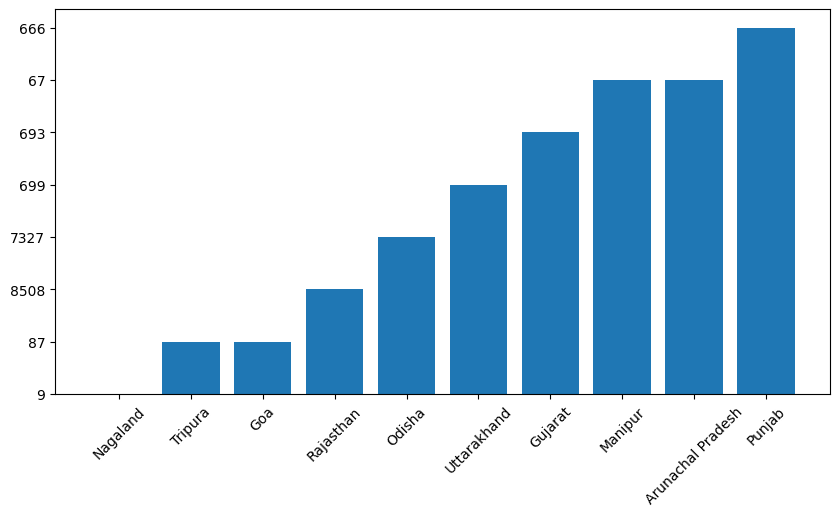

In [63]:
#sample plot
import matplotlib.pyplot as plt

top10 = final_df.sort_values(
    "Grievous_I",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["State"], top10["Grievous_I"])

plt.xticks(rotation=45)

plt.show()